
# ISR before/after



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import to_rgb

from astropy.visualization import ZScaleInterval
from lsst.ip.isr import IsrTaskLSST

from lsst.daf.butler import Butler


## Configuration

Edit `REPO` and the collection lists for your S3DF setup.

In [2]:
# ---------------------------- USER CONFIG -----------------------------------
REPO = "/sdf/data/rubin/repo/dp2_prep"     # Butler repo on S3DF, e.g. "/repo/main" or "/repo/embargo"
INSTRUMENT = "LSSTCam"

RAW_COLLECTIONS = ["LSSTCam/raw/all"]
CALIB_COLLECTIONS = ["LSSTCam/calib"]

# If you already have a run/collection with a processed post-ISR image for
# this data ID, list it here -- MODE="fetch" below will just pull it instead
# of re-running ISR. Leave as-is (or point it anywhere) if you plan to use
# MODE="run" instead.
PROCESSED_COLLECTIONS = ["LSSTCam/runs/DRP/DP2"]

# # ITL
# EXPOSURE_ID = 2025120900413
# DETECTOR_ID = 181

# EXPOSURE_ID = 2026010700038
# DETECTOR_ID = 79

# # E2V
# EXPOSURE_ID = 2025120900410
# DETECTOR_ID = 105

EXPOSURE_ID = 2026010700038
DETECTOR_ID = 45

# -----------------------------------------------------------------------------

dataId = {"instrument": INSTRUMENT, "exposure": EXPOSURE_ID, "detector": DETECTOR_ID}


## Load the raw exposure and camera geometry

In [3]:
butler = Butler(REPO)

raw = butler.get("raw", dataId=dataId, collections=RAW_COLLECTIONS)
camera = butler.get("camera", instrument=INSTRUMENT, collections=CALIB_COLLECTIONS)
defects = butler.get("defects", dataId=dataId, collections=CALIB_COLLECTIONS)

detector = camera[DETECTOR_ID]

print(f"Loaded raw exposure {EXPOSURE_ID}, detector {DETECTOR_ID} ({detector.getName()}), "
      f"raw dimensions {raw.getDimensions()}")


Loaded raw exposure 2026010700038, detector 45 (R12_S00), raw dimensions (4608, 4096)



## Get (or generate) the post-ISR image

`fetch_post_isr` tries both the older (`postISRCCD`) and newer
(`post_isr_image`) dataset type names. `run_isr` runs `IsrTaskLSST` from
scratch, pulling whatever calibs it can find and skipping the rest -- check
the `run()` call if it raises a `TypeError`, since the exact keyword names
for optional calibs have moved around between pipelines releases. Swap in
`lsst.ip.isr.IsrTask`/`IsrTaskConfig` instead of the `...LSST` variants below
if that's what your pipeline actually uses for LSSTCam.


In [4]:
config = butler.get(
    "isr_config", 
    instrument="LSSTCam", 
    exposure=EXPOSURE_ID, 
    detector=DETECTOR_ID, 
    collections=PROCESSED_COLLECTIONS,
)

linearizer = butler.get('linearizer', instrument='LSSTCam', detector = DETECTOR_ID, collections=CALIB_COLLECTIONS)
dark = butler.get('dark', instrument='LSSTCam', detector = DETECTOR_ID, collections=CALIB_COLLECTIONS)
bias = butler.get('bias', instrument='LSSTCam', detector = DETECTOR_ID, collections=CALIB_COLLECTIONS)
flat = butler.get('flat', instrument='LSSTCam', physical_filter=raw.getFilter().physicalLabel, detector = DETECTOR_ID, collections=CALIB_COLLECTIONS)
defects = butler.get('defects', instrument='LSSTCam', detector = DETECTOR_ID, collections=CALIB_COLLECTIONS)
crosstalk = butler.get('crosstalk', instrument='LSSTCam', detector = DETECTOR_ID, collections=CALIB_COLLECTIONS)
cti =  butler.get('cti', instrument='LSSTCam', detector = DETECTOR_ID, collections=CALIB_COLLECTIONS)
ptc = butler.get('ptc', instrument='LSSTCam', detector = DETECTOR_ID, collections=CALIB_COLLECTIONS)
ebf = butler.get('electroBfDistortionMatrix', instrument='LSSTCam', detector = DETECTOR_ID, collections=CALIB_COLLECTIONS)

# Get the configurations for the task
task = IsrTaskLSST(config=config)

r = task.run(
    raw,
    bias=bias,
    dark=dark,
    flat=flat,
    defects=defects,
    linearizer=linearizer,
    crosstalk=crosstalk,
    deferredChargeCalib=cti,
    ptc=ptc,
    electroBfDistortionMatrix=ebf,
)

# Get the exposure
afterIsr = r.exposure


## Helper functions: overscan boxes, mask-plane overlay, defect boxes

In [5]:

def bbox_to_rect(bbox, **kwargs):
    # Convert an lsst.geom.Box2I to a matplotlib Rectangle, aligned with
    # imshow(origin='lower') pixel conventions.
    x0, y0 = bbox.getMinX(), bbox.getMinY()
    w, h = bbox.getWidth(), bbox.getHeight()
    return mpatches.Rectangle((x0 - 0.5, y0 - 0.5), w, h, **kwargs)


def draw_overscan_boxes(ax, detector):
    # Outline each amplifier's serial (horizontal) and parallel (vertical)
    # overscan region. Only meaningful on the raw, untrimmed image.
    serial_handle = parallel_handle = None
    for amp in detector.getAmplifiers():
        serial_bbox = amp.getRawHorizontalOverscanBBox()
        parallel_bbox = amp.getRawVerticalOverscanBBox()
        if serial_bbox.getArea() > 0:
            rect = bbox_to_rect(serial_bbox, fill=False, edgecolor="red", linewidth=1.2)
            ax.add_patch(rect)
            serial_handle = rect
        if parallel_bbox.getArea() > 0:
            rect = bbox_to_rect(parallel_bbox, fill=False, edgecolor="cyan", linewidth=1.2)
            ax.add_patch(rect)
            parallel_handle = rect
    handles = [h for h in (serial_handle, parallel_handle) if h is not None]
    labels = ["Serial overscan", "Parallel overscan"][:len(handles)]
    if handles:
        ax.legend(handles, labels, loc="upper left", fontsize=8, framealpha=0.8)


# Colors for the mask planes we care about; anything else present on the
# exposure is still counted in the diagnostic printout but not drawn.
MASK_PLANE_COLORS = {
    "BAD": "red",
    "SAT": "yellow",
    "INTRP": "orange",
    "CR": "magenta",
    "EDGE": "dimgray",
    "SUSPECT": "gold",
    "NO_DATA": "black",
    "CROSSTALK": "deepskyblue",
    "UNMASKEDNAN": "purple",
}

def mask_to_rgba(mask, plane_colors=MASK_PLANE_COLORS, alpha=0.55):
    # Turn an afw Mask into an RGBA image: each set bit gets its own
    # color, everything else is fully transparent.
    arr = mask.array
    rgba = np.zeros(arr.shape + (4,), dtype=float)
    plane_dict = mask.getMaskPlaneDict()
    for planeName, color in plane_colors.items():
        if planeName not in plane_dict:
            continue
        bit = mask.getPlaneBitMask(planeName)
        set_pixels = (arr & bit) != 0
        if not set_pixels.any():
            continue
        r, g, b = to_rgb(color)
        rgba[set_pixels] = (r, g, b, alpha)
    return rgba


def draw_defect_boxes(ax, defects, **kwargs):
    # Outline each region from a Defects calibration.
    style = dict(fill=False, edgecolor="white", linewidth=1.0, linestyle="--")
    style.update(kwargs)
    for defect in defects:
        ax.add_patch(bbox_to_rect(defect.getBBox(), **style))


def zscale_limits(arr):
    interval = ZScaleInterval()
    finite = arr[np.isfinite(arr)]
    return interval.get_limits(finite)


## Diagnostics: what's actually set in the post-ISR mask

In [6]:

plane_dict = afterIsr.mask.getMaskPlaneDict()
arr = afterIsr.mask.array
print(f"{'plane':<16}{'set pixels':>12}")
for plane in sorted(plane_dict):
    bit = afterIsr.mask.getPlaneBitMask(plane)
    n = int(((arr & bit) != 0).sum())
    if n:
        print(f"{plane:<16}{n:>12d}")
print(f"\ndefects calibration: {'none found' if defects is None else f'{len(defects)} region(s)'}")


plane             set pixels
BAD                   154015
CROSSTALK             315104
EDGE                   80900
INTRP                 384798
SAT                   235463
SUSPECT                43927

defects calibration: 55 region(s)


## Plot: before vs. after ISR, side by side

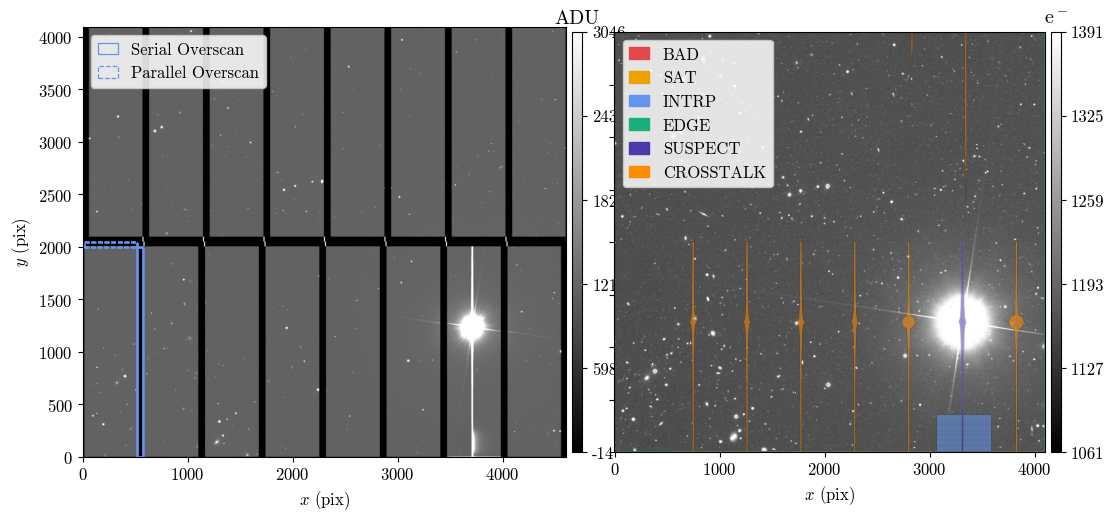

In [7]:
# Paper-style before/after figure. Only reuses bbox_to_rect / zscale_limits /
# mask_to_rgba from the "Helper functions" cell above; everything about the
# look (font, layout, colors, ticks) is self-contained here.

# ---- LaTeX-like type, sized to match body text -----------------------------
BODY_PT = 12  # set to your document's body font size (e.g. 10/11/12pt)
plt.rcParams.update({
    "text.usetex": False,  # flip to True if a working TeX install is on PATH
    "font.family": "serif",
    "font.serif": ["cmr10", "Computer Modern Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.formatter.use_mathtext": True,
    "axes.unicode_minus": False,
    "font.size": BODY_PT,
    "axes.labelsize": BODY_PT,
    "xtick.labelsize": BODY_PT ,
    "ytick.labelsize": BODY_PT ,
    "legend.fontsize": BODY_PT ,
})

# ---- colorblind-checked colors (validated with the dataviz palette tool) ---
OVERSCAN_COLORS = {"serial": "cornflowerblue", "parallel": "cornflowerblue"}
MASK_COLORS = {
    "BAD":       "#e34948",
    "SAT":       "#eda100",
    "INTRP":     "cornflowerblue",
    "CR":        "#008300",
    "EDGE":      "#1baf7a",
    "SUSPECT":   "#4a3aa7",
    "CROSSTALK": "darkorange",
    "NO_DATA":   "#3a3a3a",
}

def draw_overscan_boxes_simple(ax, detector, colors=OVERSCAN_COLORS):
    handles, labels, seen = [], [], set()
    for amp in detector.getAmplifiers():
        serial_bbox = amp.getRawHorizontalOverscanBBox()
        parallel_bbox = amp.getRawVerticalOverscanBBox()
        if serial_bbox.getArea() > 0:
            rect = bbox_to_rect(serial_bbox, fill=False, edgecolor=colors["serial"], linewidth=0.9)
            ax.add_patch(rect)
            if "serial" not in seen:
                handles.append(rect); labels.append("Serial Overscan"); seen.add("serial")
        if parallel_bbox.getArea() > 0:
            rect = bbox_to_rect(parallel_bbox, fill=False, edgecolor=colors["parallel"], linewidth=0.9, linestyle="--")
            ax.add_patch(rect)
            if "parallel" not in seen:
                handles.append(rect); labels.append("Parallel Overscan"); seen.add("parallel")
    if handles:
        ax.legend(handles, labels, loc="upper left", frameon=True, framealpha=0.85,
                  borderpad=0.4, handlelength=1.2)

def nice_cbar_ticks(vmin, vmax, n=6):
    # n >= 5 so the colorbar always shows at least 5 labeled ticks, and
    # linspace guarantees the first/last tick are exactly vmin/vmax.
    return np.linspace(vmin, vmax, n)

def format_ticks(values):
    span = values[-1] - values[0]
    decimals = 0 if span >= 20 else (1 if span >= 2 else 2)
    return [f"{v:.{decimals}f}" for v in values]

# ---- layout: identical pixel scale in both panels, colorbar heights pinned -
#      to the (smaller) post-ISR panel's height -----------------------------
PIX_SCALE = 0.00105     # inches per detector pixel -- tune for your column width
CBAR_W = 0.10           # colorbar width, inches
GAP_IMG_CBAR = 0.06     # gap between an image and its colorbar, inches
GAP_GROUP = 0.32        # gap between the two (image + colorbar) groups
MARGIN_L, MARGIN_R = 0.55, 0.35
MARGIN_B, MARGIN_T = 0.42, 0.32

raw_h_px, raw_w_px = raw.image.array.shape
after_h_px, after_w_px = afterIsr.image.array.shape

raw_w_in, raw_h_in = raw_w_px * PIX_SCALE, raw_h_px * PIX_SCALE
after_w_in, after_h_in = after_w_px * PIX_SCALE, after_h_px * PIX_SCALE
cbar_h_in = after_h_in  # requirement: both colorbars match the post-ISR panel's height

max_h_in = max(raw_h_in, after_h_in)
fig_w = MARGIN_L + raw_w_in + GAP_IMG_CBAR + CBAR_W + GAP_GROUP + after_w_in + GAP_IMG_CBAR + CBAR_W + MARGIN_R
fig_h = MARGIN_B + max_h_in + MARGIN_T

fig = plt.figure(figsize=(fig_w, fig_h))

def add_axes_in(x0, y0, w, h):
    return fig.add_axes([x0 / fig_w, y0 / fig_h, w / fig_w, h / fig_h])

# vertically center whichever panel/colorbar is shorter than the tallest one
y0_raw = MARGIN_B + (max_h_in - raw_h_in) / 2.0
y0_after = MARGIN_B + (max_h_in - after_h_in) / 2.0

x = MARGIN_L
ax0 = add_axes_in(x, y0_raw, raw_w_in, raw_h_in); x += raw_w_in + GAP_IMG_CBAR
cax0 = add_axes_in(x, y0_raw + (raw_h_in - cbar_h_in) / 2.0, CBAR_W, cbar_h_in); x += CBAR_W + GAP_GROUP
ax1 = add_axes_in(x, y0_after, after_w_in, after_h_in); x += after_w_in + GAP_IMG_CBAR
cax1 = add_axes_in(x, y0_after, CBAR_W, cbar_h_in)

# ---- panel 1: before ISR (raw), overscan regions boxed ---------------------
rawArr = raw.image.array
vmin0, vmax0 = zscale_limits(rawArr)
im0 = ax0.imshow(rawArr, origin="lower", cmap="gray", vmin=vmin0, vmax=vmax0)
ax0.set_xlim(-0.5, raw_w_px - 0.5)
ax0.set_ylim(-0.5, raw_h_px - 0.5)
ax0.set_xlabel("$x$ (pix)")
ax0.set_ylabel("$y$ (pix)")
draw_overscan_boxes_simple(ax0, detector)

ticks0 = nice_cbar_ticks(vmin0, vmax0)
cbar0 = fig.colorbar(im0, cax=cax0, ticks=ticks0)
cbar0.ax.set_yticklabels(format_ticks(ticks0))
cbar0.ax.set_title("ADU", pad=6)

# ---- panel 2: after ISR, mask planes overlaid ------------------------------
afterArr = afterIsr.image.array
vmin1, vmax1 = zscale_limits(afterArr)
im1 = ax1.imshow(afterArr, origin="lower", cmap="gray", vmin=vmin1, vmax=vmax1)
ax1.set_xlim(-0.5, after_w_px - 0.5)
ax1.set_ylim(-0.5, after_h_px - 0.5)
ax1.set_xlabel("$x$ (pix)")
ax1.tick_params(axis="y", labelleft=False)  # shares the left panel's y-scale reference

ax1.imshow(mask_to_rgba(afterIsr.mask, plane_colors=MASK_COLORS), origin="lower",
           extent=(-0.5, after_w_px - 0.5, -0.5, after_h_px - 0.5))

present = [p for p in MASK_COLORS if p in afterIsr.mask.getMaskPlaneDict()
           and (afterIsr.mask.array & afterIsr.mask.getPlaneBitMask(p)).any()]
if present:
    handles = [mpatches.Patch(color=MASK_COLORS[p], label=p) for p in present]
    ax1.legend(handles=handles, loc="upper left", frameon=True, framealpha=0.85,
               borderpad=0.4, handlelength=1.2)

ticks1 = nice_cbar_ticks(vmin1, vmax1)
cbar1 = fig.colorbar(im1, cax=cax1, ticks=ticks1)
cbar1.ax.set_yticklabels(format_ticks(ticks1))
cbar1.ax.set_title("e$^-$", pad=6)  # switch to "ADU" if your ISR config leaves gain uncorrected

plt.show()

# fig.savefig(f"isr_before_after_{EXPOSURE_ID}_det{DETECTOR_ID}.pdf", bbox_inches="tight")

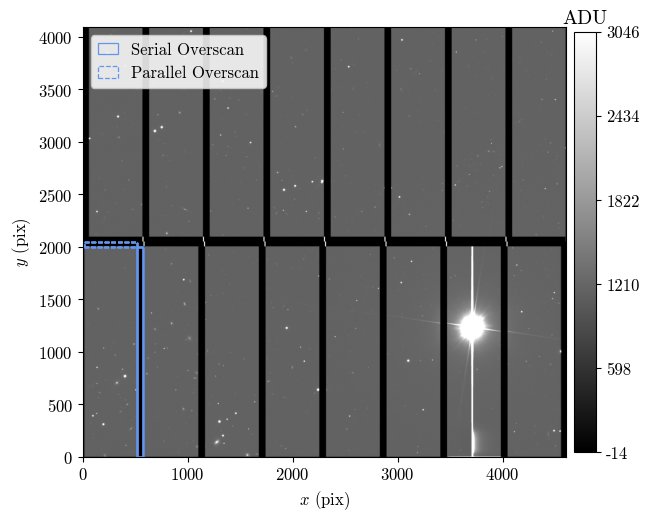

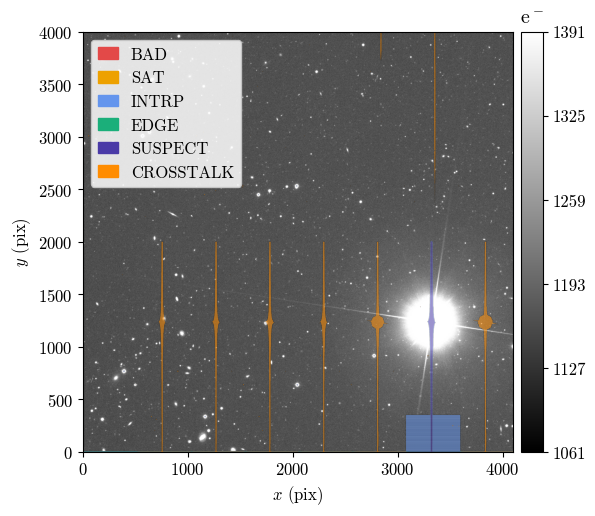

In [8]:
# Paper-style before/after figures -- two independent figures now, one per
# panel. Only reuses bbox_to_rect / zscale_limits / mask_to_rgba from the
# "Helper functions" cell above; everything about the look (font, layout,
# colors, ticks) is self-contained here.

# ---- LaTeX-like type, sized to match body text -----------------------------
BODY_PT = 12  # set to your document's body font size (e.g. 10/11/12pt)
plt.rcParams.update({
    "text.usetex": False,  # flip to True if a working TeX install is on PATH
    "font.family": "serif",
    "font.serif": ["cmr10", "Computer Modern Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.formatter.use_mathtext": True,
    "axes.unicode_minus": False,
    "font.size": BODY_PT,
    "axes.labelsize": BODY_PT,
    "xtick.labelsize": BODY_PT* 1.0,
    "ytick.labelsize": BODY_PT* 1.0,
    "legend.fontsize": BODY_PT* 1.0,
})

# ---- colorblind-checked colors (validated with the dataviz palette tool) ---
OVERSCAN_COLORS = {"serial": "cornflowerblue", "parallel": "cornflowerblue"}
MASK_COLORS = {
    "BAD":       "#e34948",
    "SAT":       "#eda100",
    "INTRP":     "cornflowerblue",
    "CR":        "#008300",
    "EDGE":      "#1baf7a",
    "SUSPECT":   "#4a3aa7",
    "CROSSTALK": "darkorange",
    "NO_DATA":   "#3a3a3a",
}

def draw_overscan_boxes_simple(ax, detector, colors=OVERSCAN_COLORS):
    handles, labels, seen = [], [], set()
    for amp in detector.getAmplifiers():
        serial_bbox = amp.getRawHorizontalOverscanBBox()
        parallel_bbox = amp.getRawVerticalOverscanBBox()
        if serial_bbox.getArea() > 0:
            rect = bbox_to_rect(serial_bbox, fill=False, edgecolor=colors["serial"], linewidth=0.9)
            ax.add_patch(rect)
            if "serial" not in seen:
                handles.append(rect); labels.append("Serial Overscan"); seen.add("serial")
        if parallel_bbox.getArea() > 0:
            rect = bbox_to_rect(parallel_bbox, fill=False, edgecolor=colors["parallel"], linewidth=0.9, linestyle="--")
            ax.add_patch(rect)
            if "parallel" not in seen:
                handles.append(rect); labels.append("Parallel Overscan"); seen.add("parallel")
    if handles:
        ax.legend(handles, labels, loc="upper left", frameon=True, framealpha=0.85,
                  borderpad=0.4, handlelength=1.2)

def nice_cbar_ticks(vmin, vmax, n=6):
    # n >= 5 so the colorbar always shows at least 5 labeled ticks, and
    # linspace guarantees the first/last tick are exactly vmin/vmax.
    return np.linspace(vmin, vmax, n)

def format_ticks(values):
    span = values[-1] - values[0]
    decimals = 0 if span >= 20 else (1 if span >= 2 else 2)
    return [f"{v:.{decimals}f}" for v in values]

def add_axes_in(fig, fig_w, fig_h, x0, y0, w, h):
    return fig.add_axes([x0 / fig_w, y0 / fig_h, w / fig_w, h / fig_h])

# ---- layout: identical pixel scale in both figures, colorbar heights ------
#      pinned to the (smaller) post-ISR panel's height ----------------------
PIX_SCALE = 0.00105     # inches per detector pixel -- tune for your column width
CBAR_W = 0.22           # colorbar width, inches (wide)
GAP_IMG_CBAR = 0.08     # gap between an image and its colorbar, inches
MARGIN_L, MARGIN_R = 0.55, 0.40
MARGIN_B, MARGIN_T = 0.42, 0.32

raw_h_px, raw_w_px = raw.image.array.shape
after_h_px, after_w_px = afterIsr.image.array.shape

raw_w_in, raw_h_in = raw_w_px * PIX_SCALE, raw_h_px * PIX_SCALE
after_w_in, after_h_in = after_w_px * PIX_SCALE, after_h_px * PIX_SCALE
cbar_h_in = after_h_in  # requirement: both figures' colorbars match the post-ISR panel's height

# ---- Figure 1: before ISR (raw), overscan regions boxed --------------------
fig1_w = MARGIN_L + raw_w_in + GAP_IMG_CBAR + CBAR_W + MARGIN_R
fig1_h = MARGIN_B + raw_h_in + MARGIN_T
fig1 = plt.figure(figsize=(fig1_w, fig1_h))

ax0 = add_axes_in(fig1, fig1_w, fig1_h, MARGIN_L, MARGIN_B, raw_w_in, raw_h_in)
cax0 = add_axes_in(fig1, fig1_w, fig1_h, MARGIN_L + raw_w_in + GAP_IMG_CBAR,
                    MARGIN_B + (raw_h_in - cbar_h_in) / 2.0, CBAR_W, cbar_h_in)

rawArr = raw.image.array
vmin0, vmax0 = zscale_limits(rawArr)
im0 = ax0.imshow(rawArr, origin="lower", cmap="gray", vmin=vmin0, vmax=vmax0)
ax0.set_xlim(-0.5, raw_w_px - 0.5)
ax0.set_ylim(-0.5, raw_h_px - 0.5)
ax0.set_xlabel("$x$ (pix)")
ax0.set_ylabel("$y$ (pix)")
draw_overscan_boxes_simple(ax0, detector)

ticks0 = nice_cbar_ticks(vmin0, vmax0)
cbar0 = fig1.colorbar(im0, cax=cax0, ticks=ticks0)
cbar0.ax.set_yticklabels(format_ticks(ticks0))
cbar0.ax.set_title("ADU", pad=6)

# ---- Figure 2: after ISR, mask planes overlaid -----------------------------
fig2_w = MARGIN_L + after_w_in + GAP_IMG_CBAR + CBAR_W + MARGIN_R
fig2_h = MARGIN_B + after_h_in + MARGIN_T
fig2 = plt.figure(figsize=(fig2_w, fig2_h))

ax1 = add_axes_in(fig2, fig2_w, fig2_h, MARGIN_L, MARGIN_B, after_w_in, after_h_in)
cax1 = add_axes_in(fig2, fig2_w, fig2_h, MARGIN_L + after_w_in + GAP_IMG_CBAR, MARGIN_B, CBAR_W, cbar_h_in)

afterArr = afterIsr.image.array
vmin1, vmax1 = zscale_limits(afterArr)
im1 = ax1.imshow(afterArr, origin="lower", cmap="gray", vmin=vmin1, vmax=vmax1)
ax1.set_xlim(-0.5, after_w_px - 0.5)
ax1.set_ylim(-0.5, after_h_px - 0.5)
ax1.set_xlabel("$x$ (pix)")
ax1.set_ylabel("$y$ (pix)")

ax1.imshow(mask_to_rgba(afterIsr.mask, plane_colors=MASK_COLORS), origin="lower",
           extent=(-0.5, after_w_px - 0.5, -0.5, after_h_px - 0.5))

present = [p for p in MASK_COLORS if p in afterIsr.mask.getMaskPlaneDict()
           and (afterIsr.mask.array & afterIsr.mask.getPlaneBitMask(p)).any()]
if present:
    handles = [mpatches.Patch(color=MASK_COLORS[p], label=p) for p in present]
    ax1.legend(handles=handles, loc="upper left", frameon=True, framealpha=0.85,
               borderpad=0.4, handlelength=1.2)

ticks1 = nice_cbar_ticks(vmin1, vmax1)
cbar1 = fig2.colorbar(im1, cax=cax1, ticks=ticks1)
cbar1.ax.set_yticklabels(format_ticks(ticks1))
cbar1.ax.set_title("e$^-$", pad=6)  # switch to "ADU" if your ISR config leaves gain uncorrected

plt.show()

fig1.savefig(f"isr_{EXPOSURE_ID}_det{DETECTOR_ID}_raw.pdf", bbox_inches="tight")
fig2.savefig(f"isr_{EXPOSURE_ID}_det{DETECTOR_ID}_afterisr.pdf", bbox_inches="tight")